In [1]:
from sdk_core import configure
from sdk_core import TwMarketData
# configure()

tw = TwMarketData()
# 取得還原股價
df = tw.get_security_price_adjusted("2025-12-31", "2330")

import os
import numpy as np
from tqdm import tqdm
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
# 將最大顯示欄位數量設為 None（代表無上限）
pd.set_option('display.max_columns', None)

import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

from backTest import BackTest
from factorAnalyzer import FactorAnalyzer_Polars


/home/kevin/project/HFTResearch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

folder_path = './data'  # 資料夾路徑
files = os.listdir(folder_path)

# 過濾掉資料夾，只留下檔案
file_names = np.array([f for f in files if os.path.isfile(os.path.join(folder_path, f))])
file_names.sort()
print(file_names[:5])

['20240102.parquet' '20240103.parquet' '20240104.parquet'
 '20240105.parquet' '20240108.parquet']


In [3]:
data = []

# 範例：處理 100 個檔案
for f in tqdm (file_names[1:]): 
    targetLabel = 'BidPrice1' 
    rankThres = 101.1
    stock_df = pd.read_parquet( f'{folder_path}/{f}' )[lambda x : x[targetLabel] * x.BidPrice1 > 0]
    try : 
        stock_df['ToRef'] = (stock_df['BidPrice1'] - stock_df.RefPrice) / stock_df.RefPrice 
        stock_df['TakerSell_CloseBP'] = ((stock_df[targetLabel]- stock_df.Close) / stock_df[targetLabel] * 10000)
        stock_df.loc[ stock_df.FutureHigh > stock_df.RefPrice*1.09 , 'TakerSell_CloseBP'] = ((stock_df[targetLabel] - stock_df.FutureHigh) / stock_df[targetLabel] * 10000)
        PriceCondition = (stock_df.ToRef > 0) & (stock_df.ToRef < 0.05)
        AmountCondition = (stock_df.day_amount_rank <= rankThres) | (stock_df.AmountRank <= rankThres)
        # preMarketCondition = (stock_df.day_amount_rank <= 50.1) | (stock_df.AmountRank <= 50.1)
        temp = stock_df[ PriceCondition & AmountCondition ].reset_index(drop=True)
        temp['Date'] = f.split('.')[0]
        data.append(temp)
    except : 
        print('Filled in ', f)
        continue
    # break

100%|██████████| 516/516 [00:36<00:00, 13.99it/s]


In [147]:
signal_df = pd.concat(data).reset_index(drop=True)

In [148]:
priceReturnColumn = ["TransTime", "QuoteCode", "ChannelSeq","TotalFillLots","BidPrice1","BidLots1", "AskPrice1","AskLots1", "RecordHigh","FutureHigh", "RefPrice" , "Close" , "Open", "Spread", "TakerSell_CloseBP" ]
signal_df[:][priceReturnColumn + ['ToRef','FillLots_atLow','day_amount_rank', 'AmountRank', 'TimeSlot','TransTime_tb']].head(10)

,TransTime,QuoteCode,ChannelSeq,TotalFillLots,BidPrice1,BidLots1,AskPrice1,AskLots1,RecordHigh,FutureHigh,RefPrice,Close,Open,Spread,TakerSell_CloseBP,ToRef,FillLots_atLow,day_amount_rank,AmountRank,TimeSlot,TransTime_tb
0,2024-01-03 13:29:53.772235,1815,1607192,7353,15.95,166,16.0,113,16.25,15.95,15.95,15.95,15.75,1.0,0.000000,1.113703e-16,-9953,155.0,95.0,13:20:00,2024-01-03 13:19:58.023847
1,2024-01-03 09:00:06.789786,2230,47341,14,170.50,1,172.0,6,172.00,175.00,167.00,167.00,172.00,3.0,205.278592,2.095808e-02,-1,65.0,NaN,None,NaT
2,2024-01-03 09:00:14.605599,2230,50161,14,171.50,1,172.0,7,172.00,175.00,167.00,167.00,172.00,1.0,262.390671,2.694611e-02,-1,65.0,NaN,None,NaT
3,2024-01-03 09:00:14.688234,2230,50191,15,170.50,1,172.0,7,172.00,175.00,167.00,167.00,172.00,3.0,205.278592,2.095808e-02,-2,65.0,NaN,None,NaT
4,2024-01-03 09:00:15.849393,2230,50695,15,171.50,1,172.0,7,172.00,175.00,167.00,167.00,172.00,1.0,262.390671,2.694611e-02,-2,65.0,NaN,None,NaT
5,2024-01-03 09:00:15.918517,2230,50716,16,170.50,1,172.0,7,172.00,175.00,167.00,167.00,172.00,3.0,205.278592,2.095808e-02,-3,65.0,NaN,None,NaT
6,2024-01-03 09:00:23.780663,2230,53889,16,170.50,2,171.5,1,172.00,175.00,167.00,167.00,172.00,2.0,205.278592,2.095808e-02,-3,65.0,NaN,None,NaT
7,2024-01-03 09:00:30.831815,2230,55927,16,170.50,2,171.0,1,172.00,175.00,167.00,167.00,172.00,1.0,205.278592,2.095808e-02,-3,65.0,NaN,None,NaT
8,2024-01-03 09:01:24.060077,2230,72335,23,170.50,5,172.0,3,172.00,175.00,167.00,167.00,172.00,3.0,205.278592,2.095808e-02,-1,65.0,NaN,None,NaT
9,2024-01-03 09:01:30.685226,2230,74229,23,170.50,5,171.5,1,172.00,175.00,167.00,167.00,172.00,2.0,205.278592,2.095808e-02,-1,65.0,NaN,None,NaT


In [149]:
signal_df = signal_df[ (signal_df.TransTime.dt.time < datetime.time(12, 0, 0)) & (signal_df.TrialMatch == 0)].reset_index(drop=True)
signal_df = signal_df[ (signal_df.TakerSell_CloseBP.abs() < 10000) ].reset_index(drop=True)
signal_df['midEdge_300sBP'] = signal_df['midEdge_300sBP']*-1

In [150]:
signal_df.head(1)

,RecvTime,TransTime,QuoteCode,ValueCode,PacketSeq,ChannelSeq,LimitStatus,TrialMatch,InOut,Overshoot,TotalFillLots,BidPrice1,BidPrice2,BidPrice3,BidPrice4,BidPrice5,BidLots1,BidLots2,BidLots3,BidLots4,BidLots5,AskPrice1,AskPrice2,AskPrice3,AskPrice4,AskPrice5,AskLots1,AskLots2,AskLots3,AskLots4,AskLots5,FillPrice,FillLots,BestBidPrice,BestBidLots,BestAskPrice,BestAskLots,OvershootHis,RefPrice,marketOpen,Open,Close,RecordHigh,RecordLow,FutureHigh,FutureLow,ToLow,ToHigh,Low_High,TickSize,TickBP,MidPrice,ToRef,ToOpen,FillLots_atLow,FillLots_atHigh,B1_A1B1,B1_B1B5,B12_B1B5,A1_A1A5,A12_A1A5,Spread,SpreadPairID,SpreadPairAsk,SpreadPairBid,SpreadPairSeq,SpreadPairElapsed,SpreadNarrowOrderTime,SpreadNarrowSide,SpreadPairCumLots,PrevSpreadPairLots,RemainSeconds,FutureAsk1_5s,FutureBid1_5s,FutureAsk1_30s,FutureBid1_30s,FutureAsk1_60s,FutureBid1_60s,FutureAsk1_120s,FutureBid1_120s,FutureAsk1_300s,FutureBid1_300s,FutureAsk1_600s,FutureBid1_600s,TakerSell_CloseBP,TakerBuy_CloseBP,midEdge_5sBP,midEdge_30sBP,midEdge_60sBP,midEdge_120sBP,midEdge_300sBP,midEdge_600sBP,allow_day_trade_mark,trading_volume,dealer_hedging_netLots,dealer_netLots,foreign_dealer_netLots,foreign_netLots,investment_netLots,margin_netLots,short_netLots,nextday_allow_day_trade_mark,trading_volume_noOdd,big_buy_lots,big_buy_ToCloseBP,big_buy_300sBP,big_sell_lots,big_sell_ToCloseBP,big_sell_300sBP,hft_participation,hft_buy_ToCloseBP,hft_buy_300sBP,hft_sell_ToCloseBP,hft_sell_300sBP,day_amount_rank,day_lots_rank,TransTime_tb,TimeSlot,AmountRank,netAmountRank,TotalFillLotsRank,netTotalFillLotsRank,ToRefRank,Date
0,2024-01-03 09:00:06.789786,2024-01-03 09:00:06.789786,2230,2230,451853,47341,0,0,-1,0,14,170.5,170.0,169.5,169.0,168.0,1,9,1,2,7,172.0,172.5,173.0,173.5,174.0,6,3,8,2,10,171.5,1,0.0,0,0.0,0,NaN,167.0,True,172.0,167.0,172.0,171.5,175.0,167.0,0.002994,0.0,1.0,0.5,29.325513,171.25,0.020958,-0.00436,-1,12,0.142857,0.05,0.5,0.206897,0.310345,3.0,1,172.0,170.5,1,0.0,7.815813,1.0,1,13,15893.210214,172.0,170.5,172.0,170.5,171.5,170.5,172.0,171.5,174.0,173.0,175.0,174.5,205.278592,-205.278592,0.0,0.0,-14.59854,29.19708,-131.386861,204.379562,X,1444000.0,21056.0,-9000.0,0.0,203000.0,0.0,136.0,58.0,X,1444.0,48.0,13.328215,-25.672346,15.0,13.222251,18.863941,0.02566,105.531108,41.259792,-43.817026,-51.319648,65.0,104.0,NaT,None,NaN,NaN,NaN,NaN,NaN,20240103


In [78]:
%load_ext autoreload
%autoreload 

import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from backTest import BackTest
from factorAnalyzer import FactorAnalyzer_Polars

In [151]:
signal_df['TakerSell_CloseBP_net'] = signal_df.TakerSell_CloseBP - signal_df.groupby('Date').TakerSell_CloseBP.transform('mean')

In [135]:
# ================= 使用範例 =================
# 假設 df 是您準備好的 Tick 資料
based_columns = ['QuoteCode', 'ChannelSeq', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1','BidLots1', 'BidLots5', 'AskPrice1', 'AskLots1', 'AskLots5', 'FillLots']
feature_columns = ['ToLow', 'ToHigh', 'Low_High', 'TickSize', 'TickBP', 'ToRef', 'ToOpen', 'FillLots_atLow', 'FillLots_atHigh', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'SpreadPairID', 'SpreadPairSeq', 'SpreadPairElapsed', 'SpreadNarrowSide', 'SpreadPairCumLots', 'PrevSpreadPairLots', 'RemainSeconds']
cross_columns = ['AmountRank', 'netAmountRank', 'TotalFillLotsRank', 'netTotalFillLotsRank', 'ToRefRank']
day_columns = ['dealer_hedging_netLots', 'dealer_netLots', 'foreign_dealer_netLots', 'foreign_netLots', 'investment_netLots', 'margin_netLots', 'short_netLots', 'nextday_allow_day_trade_mark', 'trading_volume_noOdd', 'big_buy_lots', 'big_buy_ToCloseBP', 'big_buy_300sBP', 'big_sell_lots', 'big_sell_ToCloseBP', 'big_sell_300sBP', 'hft_participation', 'hft_buy_ToCloseBP', 'hft_buy_300sBP', 'hft_sell_ToCloseBP', 'hft_sell_300sBP', 'day_amount_rank', 'day_lots_rank']
# # 
feature = based_columns + feature_columns + cross_columns + day_columns

for label in ['TakerSell_CloseBP' , 'midEdge_300sBP'] : 
    analyzer = FactorAnalyzer_Polars(signal_df, label_col=label, feature_cols=feature, time_col='Date', weight_col='BidPrice1')
    top_factors_df = analyzer.screen_single_factors(split_date='2025-12-01', n_quantiles=5, spread_threshold=40.0)
    condition_sample = (top_factors_df.Stability > 0.5) & (top_factors_df.IS_Spread * top_factors_df.IS_IC.apply(np.sign) > 20 )
    condition_weight = (top_factors_df.W_Stability > 0.5) & (top_factors_df.IS_W_Spd * top_factors_df.IS_W_IC.apply(np.sign) > 20 )
    top_factors = top_factors_df[ condition_sample | condition_weight ].Feature.to_list()
    break
    # signal_df = train_and_predict_ridge(signal_df, top_factors, label, train_date='2025-01-01')

>>> 初始化資料並轉換為 Polars 極速引擎...
✅ Polars 引擎準備完畢！資料筆數: 7,478,164 筆 | 有效特徵數: 59

🚀 開始單一因子全局海選 (Polars 極速引擎版 | 純數值輸出)
⏱️ 樣本切割點: 2025-12-01 | 🎯 過濾條件: |Spread| > 40.0


⚙️ 因子運算進度:  67%|██████▋   | 39/58 [00:28<00:13,  1.45it/s]/home/kevin/project/HFTResearch/src/research/factorAnalyzer.py:97: RuntimeWarning: invalid value encountered in scalar divide
  w_ic = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
⚙️ 因子運算進度: 100%|██████████| 58/58 [00:41<00:00,  1.41it/s]


✅ 篩選完成！共找到 39 個 Spread > 40.0 的強勢因子：

             Feature   IS_IC  OOS_IC  Stability  IS_Spread  OOS_Spread  IS_W_IC  OOS_W_IC  W_Stability  IS_W_Spd  OOS_W_Spd
          ChannelSeq -0.1833 -0.0934     0.5094     -77.32      -69.66  -0.1931   -0.0172       0.0891    -84.77      -5.59
   hft_participation  0.0242  0.0832     3.4393       8.80       92.45  -0.0201    0.1434      -7.1415    -23.00     107.55
              ToOpen -0.0900 -0.0741     0.8234     -54.20      -66.81  -0.0827   -0.0417       0.5035    -60.01     -89.50
       RemainSeconds -0.0497 -0.0722     1.4513       0.34      -58.88  -0.0490    0.0215      -0.4375      0.97      45.34
trading_volume_noOdd  0.0106  0.0651     6.1389      -3.25       59.95   0.0219    0.1223       5.5824      9.50      97.31
  big_sell_ToCloseBP -0.0803 -0.0628     0.7815     -23.41      -34.39  -0.0600   -0.0105       0.1748    -35.53      88.03
            Low_High -0.0577 -0.0618     1.0700     -40.17      -51.35  -0.0572   -0.0523    

In [136]:
top_factors

['ChannelSeq',
 'ToOpen',
 'big_sell_ToCloseBP',
 'Low_High',
 'ToHigh',
 'FillLots_atHigh']

In [137]:
import pandas as pd
from sklearn.linear_model import Ridge

def train_and_predict_ridge(signal_df, X_list, Y_col):
    print(f"🔍 目前預測目標: {Y_col}")
    
    # 計算 0.1% 的閾值 (threshold)
    total_rows = len(signal_df)
    threshold = total_rows * 0.001
    print(f"📊 資料總筆數: {total_rows} | 0.1% 容忍閾值: {threshold:.2f} 筆")
    
    # 建立分類清單
    cols_to_drop_rows = []
    cols_to_remove_from_X = []
    
    # ==========================================
    # 1. 檢查 X_list 裡面的 NaN 狀況並分類
    # ==========================================
    for col in X_list:
        nan_count = signal_df[col].isna().sum()
        if nan_count > 0:
            if nan_count < threshold:
                # NaN 數量小於 0.1%，標記為準備 dropna (刪除資料列)
                cols_to_drop_rows.append(col)
            else:
                # NaN 數量大於等於 0.1%，標記為準備移除特徵
                cols_to_remove_from_X.append(col)
                
    # ==========================================
    # 2. 執行移除特徵 (Columns) 動作
    # ==========================================
    # 產生真正要進模型的 current_X
    current_X = [col for col in X_list if col not in cols_to_remove_from_X]
    
    if cols_to_remove_from_X:
        print(f"⚠️ 以下特徵 NaN 數量超過閾值，已從 X_list 中移除：")
        for col in cols_to_remove_from_X:
            nan_count = signal_df[col].isna().sum()
            print(f"   - {col} (NaN: {nan_count} 筆)")
            
    # ==========================================
    # 3. 處理 Y 的 NaN 與執行 dropna (刪除資料列)
    # ==========================================
    # 確保 Y 如果有 NaN 也一併剔除該筆資料
    if signal_df[Y_col].isna().sum() > 0 and Y_col not in cols_to_drop_rows:
        cols_to_drop_rows.append(Y_col)
        
    if cols_to_drop_rows:
        print(f"🧹 以下欄位 NaN 數量極少 (低於閾值)，將直接剔除帶有 NaN 的資料列：")
        for col in cols_to_drop_rows:
            nan_count = signal_df[col].isna().sum()
            print(f"   - {col} (NaN: {nan_count} 筆)")
            
        # 實際執行 dropna，並更新 signal_df
        signal_df = signal_df.dropna(subset=cols_to_drop_rows).copy()
        print(f"✅ 剔除後剩餘資料總筆數: {len(signal_df)}")
        
    # ==========================================
    # 4. 顯示最終要進模型的 X_list
    # ==========================================
    print("-" * 40)
    print(f"🚀 最終使用的 X_list (共 {len(current_X)} 個特徵):")
    print(current_X)
    print("-" * 40)
    
    # 安全機制：如果所有 X 都被砍光了，就拋出錯誤
    if not current_X:
        raise ValueError("所有的 X 特徵都因為 NaN 太多被移除了，無法建立模型！")

    # ==========================================
    # 5. 處理時間與切分訓練集
    # ==========================================
    train_mask = signal_df['Date'].astype(int) < 20250101
    lot_mask = signal_df.groupby(['Date','QuoteCode']).BidPrice1.cumsum()/10 < 500 
    train_df = signal_df[train_mask&lot_mask]
    
    # ==========================================
    # 6. 建立並訓練 Ridge 模型
    # ==========================================
    model = Ridge(alpha=1.0)
    model.fit(train_df[current_X], train_df[Y_col])
    
    # ==========================================
    # 7. 對整份 signal_df 進行預測
    # ==========================================
    pred_col_name = f"{Y_col}_pred"
    signal_df[pred_col_name] = model.predict(signal_df[current_X])
    
    return signal_df

In [138]:
signal_df = train_and_predict_ridge(signal_df, top_factors, label)

🔍 目前預測目標: TakerSell_CloseBP
📊 資料總筆數: 7478164 | 0.1% 容忍閾值: 7478.16 筆
⚠️ 以下特徵 NaN 數量超過閾值，已從 X_list 中移除：
   - big_sell_ToCloseBP (NaN: 51724 筆)
----------------------------------------
🚀 最終使用的 X_list (共 5 個特徵):
['ChannelSeq', 'ToOpen', 'Low_High', 'ToHigh', 'FillLots_atHigh']
----------------------------------------


/home/kevin/project/HFTResearch/.venv/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.0918230201834736e-17.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


In [139]:
signal_df.TakerSell_CloseBP_pred.describe()

count    7.478164e+06
mean     7.086845e+01
std      5.871857e+01
min     -5.017027e+02
25%      5.014733e+01
50%      7.176001e+01
75%      9.921271e+01
max      8.016292e+02
Name: TakerSell_CloseBP_pred, dtype: float64

In [142]:
condition = pd.Series( [True for i in range(len(signal_df))] )
condition = signal_df.TakerSell_CloseBP_pred > 100
# condition = (signal_df.big_sell_ToCloseBP > 20 ) & (signal_df.InOut < 0 ) & (signal_df.FillLots > signal_df.big_buy_lots)
# condition = condition | ((signal_df.Spread == 1 )&((signal_df.SpreadPairSeq<3)|(signal_df.SpreadPairID > 7)))
# condition = condition  & ((signal_df.netTotalFillLotsRank>1800)|(signal_df.netAmountRank>1800))
print( signal_df[condition].TakerSell_CloseBP.describe() )
print('')
print( 'cap BP : '+str( round((signal_df[condition].TakerSell_CloseBP * signal_df[condition].BidPrice1).sum() / signal_df[condition].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

condition_recent = condition & (signal_df.Date.astype(int) > 20260101)
print( signal_df[condition_recent].TakerSell_CloseBP.describe() )
print('')
print( 'cap BP : '+str( round((signal_df[condition_recent].TakerSell_CloseBP * signal_df[condition_recent].BidPrice1).sum() / signal_df[condition_recent].BidPrice1.sum() ,2 ))  )
print( 'averge prod num : '+str( round(signal_df[condition_recent].groupby('Date').QuoteCode.nunique().mean(), 2)  ))

count    1.832087e+06
mean     1.401953e+02
std      2.830634e+02
min     -1.784387e+03
25%      5.578801e+01
50%      1.551724e+02
75%      2.862254e+02
max      1.417798e+03
Name: TakerSell_CloseBP, dtype: float64

cap BP : 138.91
averge prod num : 16.28
count    106906.000000
mean         55.944809
std         410.750331
min        -993.485342
25%        -166.453265
50%         113.122172
75%         310.218978
max        1283.018868
Name: TakerSell_CloseBP, dtype: float64

cap BP : 45.95
averge prod num : 15.72


In [143]:
signal_df = signal_df[condition].reset_index(drop=True)


In [144]:
print(signal_df.columns.tolist())

['RecvTime', 'TransTime', 'QuoteCode', 'ValueCode', 'PacketSeq', 'ChannelSeq', 'LimitStatus', 'TrialMatch', 'InOut', 'Overshoot', 'TotalFillLots', 'BidPrice1', 'BidPrice2', 'BidPrice3', 'BidPrice4', 'BidPrice5', 'BidLots1', 'BidLots2', 'BidLots3', 'BidLots4', 'BidLots5', 'AskPrice1', 'AskPrice2', 'AskPrice3', 'AskPrice4', 'AskPrice5', 'AskLots1', 'AskLots2', 'AskLots3', 'AskLots4', 'AskLots5', 'FillPrice', 'FillLots', 'BestBidPrice', 'BestBidLots', 'BestAskPrice', 'BestAskLots', 'OvershootHis', 'RefPrice', 'marketOpen', 'Open', 'Close', 'RecordHigh', 'RecordLow', 'FutureHigh', 'FutureLow', 'ToLow', 'ToHigh', 'Low_High', 'TickSize', 'TickBP', 'MidPrice', 'ToRef', 'ToOpen', 'FillLots_atLow', 'FillLots_atHigh', 'B1_A1B1', 'B1_B1B5', 'B12_B1B5', 'A1_A1A5', 'A12_A1A5', 'Spread', 'SpreadPairID', 'SpreadPairAsk', 'SpreadPairBid', 'SpreadPairSeq', 'SpreadPairElapsed', 'SpreadNarrowOrderTime', 'SpreadNarrowSide', 'SpreadPairCumLots', 'PrevSpreadPairLots', 'RemainSeconds', 'FutureAsk1_5s', 'Futu

In [145]:
## 部位留存
signal_df['PosLots'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumcount') + 1
signal_df['Position'] = signal_df.groupby(['Date', 'QuoteCode']).BidPrice1.transform('cumsum') / 10
signalwithRisk_df = signal_df[ (~((signal_df.Position > 500)&(signal_df.PosLots >1))) & (signal_df.BidPrice1<2000)].reset_index(drop=True)
# signalwithRisk_df = signal_df[ (signal_df.BidPrice1>2000)&(signal_df.PosLots ==1)].reset_index(drop=True)


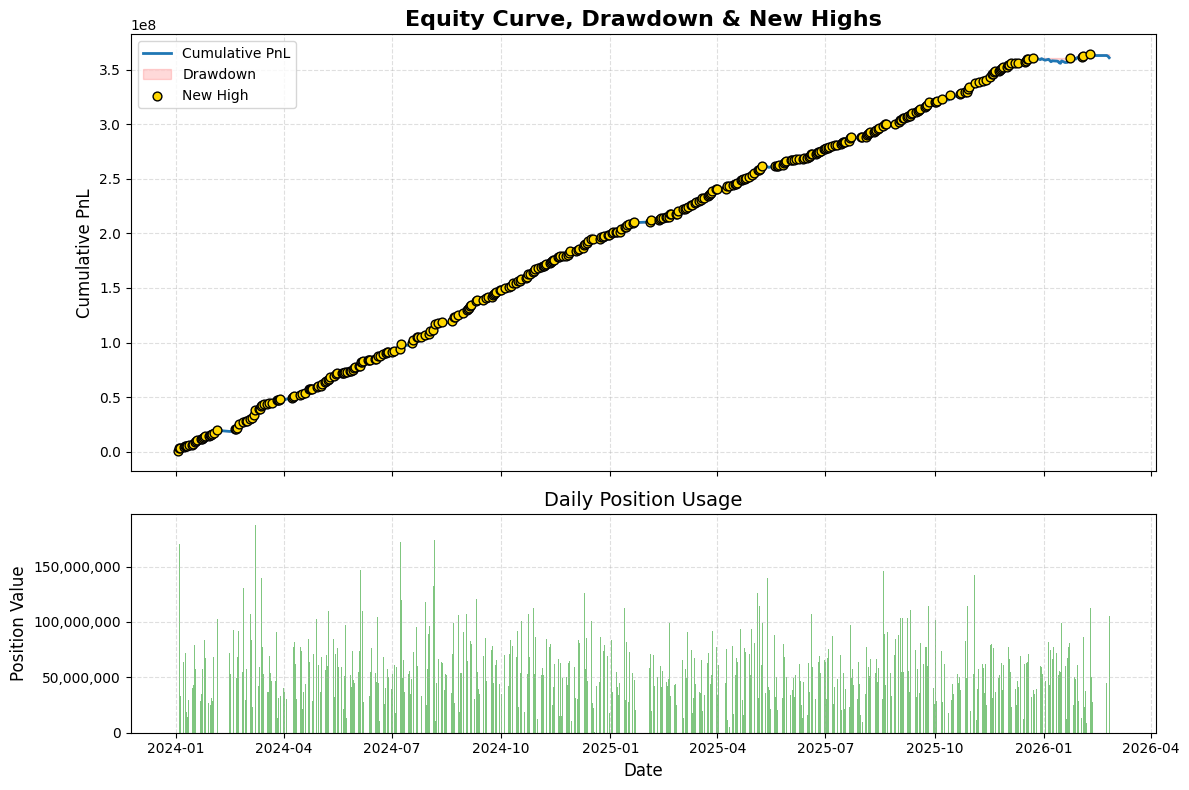


指標                 | 數值           

------------------ 基礎回報 ------------------
總報酬 (萬)           : 36,089.37
近一年報酬（萬）      : 14,059.18
風報比                  : 74.84
年化 Sharpe          : 11.26
創高最長費時 (天)     : 20
平均每日交易商品數   : 15.77

------------------ 勝率與效率 ------------------
年報酬率（基於平均部位）: 289.72%
近一年報酬率（近一年平均部位）: 253.82%
勝率 (日/單筆)      : 78.64% / 78.60%
平均BP (單/單位)   : 110.83 / 120.7163

------------------ 風控與部位 ------------------
單日最大虧損（萬） : -193.11 萬
MDD金額/佔平均比   : -482.25 萬 / 8.31%
平均/最大部位(萬)  : 5,805.05 / 18,776.77
平均最大單一商品比  : 11.77%



In [146]:
bt = BackTest(signalwithRisk_df)
results = bt.run_analysis()